# Logistic Regression

Notebook này dùng để ghi chú và thực hành **Logistic Regression**.

Nội dung chính:

1. Logistic Regression là gì?
2. Sigmoid là gì?
3. Công thức toán học
4. Ví dụ tính tay
5. Demo Python với Sigmoid
6. Demo Logistic Regression bằng `scikit-learn`
7. Bài tập tự luyện


## 1. Logistic Regression là gì?

**Logistic Regression** là một thuật toán Machine Learning dùng cho bài toán **classification**.

Thường gặp nhất là **binary classification**, tức là phân loại thành 2 nhóm.

Ví dụ:

| Bài toán | Output |
|---|---|
| Email có spam không? | Spam / Not spam |
| Học sinh có pass không? | Pass / Fail |
| Khách hàng có mua hàng không? | Buy / Not buy |
| Bệnh nhân có bệnh không? | Yes / No |

Dù tên có chữ **Regression**, Logistic Regression không dùng để dự đoán số liên tục như Linear Regression.

Nó dùng để dự đoán **xác suất** rồi phân loại.


## 2. Ý tưởng chính

Logistic Regression bắt đầu giống Linear Regression:

$$
z = wx + b
$$

Với nhiều biến đầu vào:

$$
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

Sau đó đưa $z$ qua hàm **sigmoid** để biến kết quả thành xác suất:

$$
\hat{y} = \sigma(z)
$$

Hoặc viết đầy đủ:

$$
\hat{y} = \sigma(w_1x_1 + w_2x_2 + \cdots + w_nx_n + b)
$$

Trong đó:

| Ký hiệu | Ý nghĩa |
|---|---|
| $x$ | input feature |
| $w$ | weight |
| $b$ | bias |
| $z$ | giá trị tuyến tính trước khi đưa vào sigmoid |
| $\hat{y}$ | xác suất model dự đoán |


## 3. Sigmoid là gì?

**Sigmoid** là một hàm dùng để biến một số bất kỳ thành giá trị nằm trong khoảng từ 0 đến 1.

Công thức:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Trong đó:

| Ký hiệu | Ý nghĩa |
|---|---|
| $\sigma(z)$ | giá trị sau khi qua sigmoid |
| $z$ | input của sigmoid |
| $e$ | số Euler, xấp xỉ $2.718$ |
| $e^{-z}$ | hàm mũ |

Sigmoid giống như một cái máy nén:

$$
-\infty < z < +\infty
$$

thành:

$$
0 < \sigma(z) < 1
$$

Vì output nằm trong khoảng 0 đến 1 nên ta có thể hiểu nó là **probability**.


## 4. Tại sao cần Sigmoid?

Nếu chỉ dùng công thức tuyến tính:

$$
z = wx + b
$$

thì kết quả có thể là:

$$
-20, 0, 5, 100
$$

Những số này không phải xác suất.

Trong classification, ta cần xác suất nằm trong khoảng:

$$
0 \leq P(y=1|x) \leq 1
$$

Vì vậy Logistic Regression dùng sigmoid để biến $z$ thành xác suất:

$$
P(y=1|x) = \sigma(z)
$$


## 5. Ví dụ tính tay với Sigmoid

### Trường hợp 1: $z = 0$

$$
\sigma(0) = \frac{1}{1 + e^0}
$$

Vì:

$$
e^0 = 1
$$

nên:

$$
\sigma(0) = \frac{1}{1+1} = \frac{1}{2} = 0.5
$$

Ý nghĩa: model đang ở mức trung lập, xác suất class 1 là 50%.

---

### Trường hợp 2: $z = 3$

$$
\sigma(3) = \frac{1}{1 + e^{-3}}
$$

$$
\sigma(3) \approx 0.9526
$$

Ý nghĩa: xác suất thuộc class 1 là khoảng 95.26%.

---

### Trường hợp 3: $z = -3$

$$
\sigma(-3) = \frac{1}{1 + e^3}
$$

$$
\sigma(-3) \approx 0.0474
$$

Ý nghĩa: xác suất thuộc class 1 chỉ khoảng 4.74%.


In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

values = [-10, -3, 0, 3, 10]

for z in values:
    print(f"z = {z:>3} -> sigmoid(z) = {sigmoid(z):.4f}")


z = -10 -> sigmoid(z) = 0.0000
z =  -3 -> sigmoid(z) = 0.0474
z =   0 -> sigmoid(z) = 0.5000
z =   3 -> sigmoid(z) = 0.9526
z =  10 -> sigmoid(z) = 1.0000


## 6. Vẽ đồ thị Sigmoid

Đường sigmoid có dạng chữ S.

Khi $z$ rất nhỏ, sigmoid gần 0.

Khi $z = 0$, sigmoid bằng 0.5.

Khi $z$ rất lớn, sigmoid gần 1.


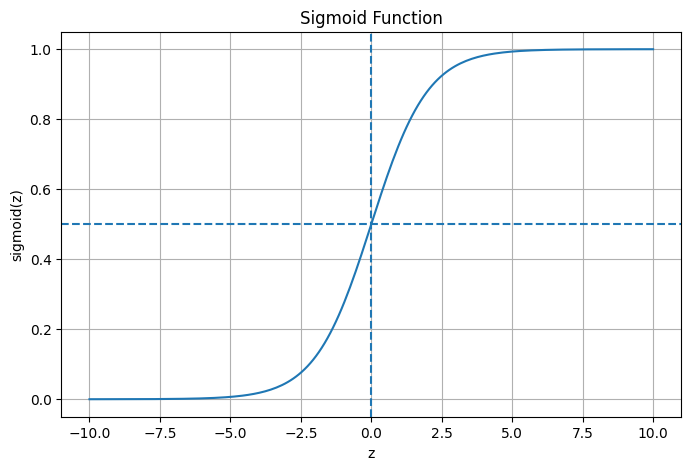

In [2]:
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, y)
plt.axhline(0.5, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid(True)
plt.show()


## 7. Decision Threshold

Sau khi có xác suất, Logistic Regression cần chuyển xác suất thành class.

Thông thường dùng threshold là 0.5:

$$
\hat{y} \geq 0.5 \Rightarrow \text{class } 1
$$

$$
\hat{y} < 0.5 \Rightarrow \text{class } 0
$$

Ví dụ:

| Probability | Prediction |
|---|---|
| 0.82 | class 1 |
| 0.31 | class 0 |
| 0.50 | class 1 nếu dùng điều kiện $\geq 0.5$ |


In [3]:
probabilities = [0.12, 0.49, 0.5, 0.77, 0.91]

for p in probabilities:
    predicted_class = 1 if p >= 0.5 else 0
    print(f"Probability = {p:.2f} -> Predicted class = {predicted_class}")


Probability = 0.12 -> Predicted class = 0
Probability = 0.49 -> Predicted class = 0
Probability = 0.50 -> Predicted class = 1
Probability = 0.77 -> Predicted class = 1
Probability = 0.91 -> Predicted class = 1


## 8. Loss Function trong Logistic Regression

Logistic Regression thường dùng **Binary Cross Entropy Loss**.

Công thức cho một sample:

$$
L(y, \hat{y}) = - \left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

Trong đó:

| Ký hiệu | Ý nghĩa |
|---|---|
| $y$ | nhãn thật, chỉ có thể là 0 hoặc 1 |
| $\hat{y}$ | xác suất model dự đoán |
| $\log$ | log tự nhiên |

Ý nghĩa:

- Nếu model dự đoán đúng và tự tin → loss nhỏ.
- Nếu model dự đoán sai mà còn tự tin → loss rất lớn.

Ví dụ:

Nếu $y = 1$ và $\hat{y} = 0.9$ thì model dự đoán tốt.

Nếu $y = 1$ và $\hat{y} = 0.1$ thì model dự đoán rất sai.


In [4]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

examples = [
    (1, 0.9),
    (1, 0.1),
    (0, 0.1),
    (0, 0.9),
]

for y_true, y_pred in examples:
    loss = binary_cross_entropy(y_true, y_pred)
    print(f"y_true = {y_true}, y_pred = {y_pred} -> loss = {loss:.4f}")


y_true = 1, y_pred = 0.9 -> loss = 0.1054
y_true = 1, y_pred = 0.1 -> loss = 2.3026
y_true = 0, y_pred = 0.1 -> loss = 0.1054
y_true = 0, y_pred = 0.9 -> loss = 2.3026


## 9. Demo đơn giản: dự đoán Pass / Fail theo số giờ học

Giả sử ta có dữ liệu:

| Hours studied | Result |
|---|---|
| 1 | Fail |
| 2 | Fail |
| 3 | Fail |
| 4 | Fail |
| 5 | Pass |
| 6 | Pass |
| 7 | Pass |
| 8 | Pass |

Ta mã hóa:

$$
\text{Fail} = 0
$$

$$
\text{Pass} = 1
$$


In [5]:
import pandas as pd

data = pd.DataFrame({
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'pass_exam':     [0, 0, 0, 0, 1, 1, 1, 1]
})

data


,hours_studied,pass_exam
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


In [6]:
from sklearn.linear_model import LogisticRegression

X = data[['hours_studied']]
y = data['pass_exam']

model = LogisticRegression()
model.fit(X, y)

print('Weight w:', model.coef_[0][0])
print('Bias b:', model.intercept_[0])


Weight w: 1.1697993675705605
Bias b: -5.264107913297968


Sau khi train, model học được hai tham số:

$$
w
$$

và

$$
b
$$

Công thức dự đoán là:

$$
z = wx + b
$$

$$
\hat{y} = \sigma(z)
$$

Nếu $\hat{y} \geq 0.5$ thì dự đoán Pass.

Nếu $\hat{y} < 0.5$ thì dự đoán Fail.


In [7]:
test_hours = pd.DataFrame({'hours_studied': [2, 4, 5, 6, 9]})

predicted_probabilities = model.predict_proba(test_hours)[:, 1]
predicted_classes = model.predict(test_hours)

result = test_hours.copy()
result['probability_pass'] = predicted_probabilities
result['predicted_class'] = predicted_classes
result['prediction'] = result['predicted_class'].map({0: 'Fail', 1: 'Pass'})

result


,hours_studied,probability_pass,predicted_class,prediction
0,2,0.050955,0,Fail
1,4,0.357803,0,Fail
2,5,0.642192,1,Pass
3,6,0.852543,1,Pass
4,9,0.994853,1,Pass


c:\Users\ASUS\Documents\PROJECT\intro_to_AI\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


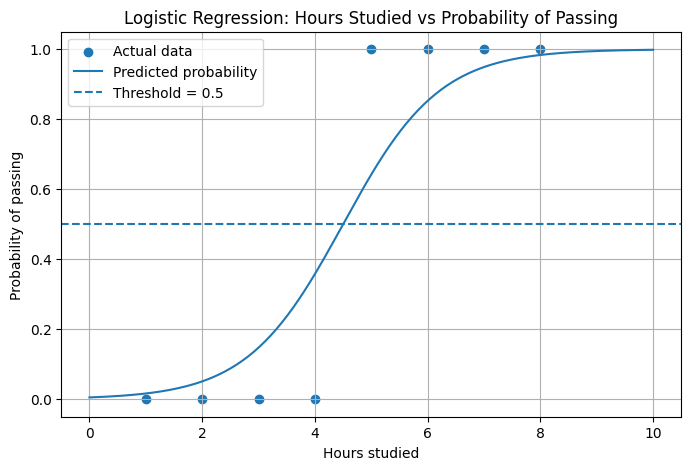

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(data['hours_studied'], data['pass_exam'], label='Actual data')

x_range = np.linspace(0, 10, 200).reshape(-1, 1)
prob_pass = model.predict_proba(x_range)[:, 1]

plt.plot(x_range, prob_pass, label='Predicted probability')
plt.axhline(0.5, linestyle='--', label='Threshold = 0.5')
plt.title('Logistic Regression: Hours Studied vs Probability of Passing')
plt.xlabel('Hours studied')
plt.ylabel('Probability of passing')
plt.legend()
plt.grid(True)
plt.show()


## 10. Đánh giá model

Với classification, ta thường dùng các metric như:

| Metric | Ý nghĩa |
|---|---|
| Accuracy | Tỷ lệ dự đoán đúng |
| Precision | Trong các mẫu model dự đoán là 1, có bao nhiêu mẫu thật sự là 1 |
| Recall | Trong các mẫu thật sự là 1, model tìm ra được bao nhiêu |
| F1-score | Trung bình điều hòa giữa Precision và Recall |

Công thức Accuracy:

$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
$$


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X)

print('Accuracy:', accuracy_score(y, y_pred))
print('\nConfusion Matrix:')
print(confusion_matrix(y, y_pred))
print('\nClassification Report:')
print(classification_report(y, y_pred))


Accuracy: 1.0

Confusion Matrix:
[[4 0]
 [0 4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## 11. Tổng kết ngắn gọn

Logistic Regression có thể nhớ bằng công thức tổng quát:

$$
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
\hat{y} \geq 0.5 \Rightarrow \text{class } 1
$$

$$
\hat{y} < 0.5 \Rightarrow \text{class } 0
$$

Cách hiểu đơn giản:

> Logistic Regression = Linear Function + Sigmoid + Threshold

Nó là nền tảng quan trọng để học Neural Network sau này, vì Neural Network cũng thường có dạng:

$$
\text{Linear Combination} \rightarrow \text{Activation Function}
$$


## 12. Bài tập tự luyện

### Bài 1

Tính sigmoid cho các giá trị sau:

$$
z = -2, 0, 2
$$

Sau đó nhận xét giá trị nào gần 0, giá trị nào bằng 0.5, giá trị nào gần 1.

---

### Bài 2

Cho model:

$$
z = 0.8x - 3
$$

Với $x = 5$, hãy tính:

$$
z
$$

và:

$$
\sigma(z)
$$

Sau đó kết luận class dự đoán nếu threshold là 0.5.

---

### Bài 3

Tự tạo dataset nhỏ gồm:

- số giờ học
- kết quả pass/fail

Sau đó train Logistic Regression và thử dự đoán cho học sinh học 3 giờ, 5 giờ, 7 giờ.


In [ ]:
# Gợi ý làm bài 1

z_values = np.array([-2, 0, 2])
sigmoid_values = sigmoid(z_values)

for z, s in zip(z_values, sigmoid_values):
    print(f"z = {z}, sigmoid(z) = {s:.4f}")
